In [1]:
!wget https://naciscdn.org/naturalearth/packages/natural_earth_vector.zip
!mkdir natural_earth_vector
!unzip natural_earth_vector.zip -d ./natural_earth_vector

--2026-02-27 11:02:13--  https://naciscdn.org/naturalearth/packages/natural_earth_vector.zip
Resolving naciscdn.org (naciscdn.org)... 13.33.82.62, 13.33.82.86, 13.33.82.127, ...
Connecting to naciscdn.org (naciscdn.org)|13.33.82.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 587029538 (560M) [application/zip]
Saving to: ‘natural_earth_vector.zip.1’

natural_earth_vecto 100%[===================>] 559.83M  55.9MB/s    in 9.9s    

2026-02-27 11:02:23 (56.4 MB/s) - ‘natural_earth_vector.zip.1’ saved [587029538/587029538]



In [11]:
import pandas as pd
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patheffects
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm

import re
import pycountry


from pathlib import Path

# World

In [12]:
world = gpd.read_file('./natural_earth_vector/10m_cultural/ne_10m_admin_0_countries.shp')

# hmc metadata

In [13]:
metadata_path = Path("/data/cctm/youn/human_microbiome_compendium/sample_metadata.tsv")
metadata = pd.read_csv(metadata_path, sep='\t')

amgut_metadata = metadata.loc[metadata['project'] == 'PRJEB11419']
display(amgut_metadata)
display(list(pd.unique(amgut_metadata['geo_loc_name'])))

,srs,project,srr,library_strategy,library_source,pubdate,total_bases,instrument,geo_loc_name,iso,region
10036,ERS6283733,PRJEB11419,ERR5752539,AMPLICON,METAGENOMIC,2021-04-23 21:16:01,7388306.0,Illumina MiSeq,NaN,unknown,unknown
10037,ERS6283732,PRJEB11419,ERR5752538,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,5753252.0,Illumina MiSeq,NaN,unknown,unknown
10038,ERS6283731,PRJEB11419,ERR5752537,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,9437919.0,Illumina MiSeq,NaN,unknown,unknown
10039,ERS6283730,PRJEB11419,ERR5752536,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,7725916.0,Illumina MiSeq,NaN,unknown,unknown
10040,ERS6283729,PRJEB11419,ERR5752535,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,5515804.0,Illumina MiSeq,NaN,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...
49049,ERS6630002,PRJEB11419,ERR6148986,AMPLICON,METAGENOMIC,2021-07-03 07:41:05,3282381.0,Illumina MiSeq,NaN,unknown,unknown
49050,ERS6630001,PRJEB11419,ERR6148985,AMPLICON,METAGENOMIC,2021-07-03 07:41:05,3425973.0,Illumina MiSeq,NaN,unknown,unknown
49051,ERS6630000,PRJEB11419,ERR6148984,AMPLICON,METAGENOMIC,2021-07-03 07:41:05,2402694.0,Illumina MiSeq,NaN,unknown,unknown
49052,ERS6629999,PRJEB11419,ERR6148983,AMPLICON,METAGENOMIC,2021-07-03 07:41:05,3362257.0,Illumina MiSeq,NaN,unknown,unknown


[nan,
 'united kingdom:unspecified',
 'usa:nc',
 'usa:unspecified',
 'usa:ca',
 'usa:ma',
 'france:unspecified',
 'usa:tx',
 'usa:dc',
 'usa:wa',
 'usa:co',
 'iceland:unspecified',
 'austria:unspecified',
 'sweden:unspecified',
 'canada:unspecified',
 'switzerland:unspecified',
 'usa:mn',
 'usa:pa',
 'usa:hi',
 'usa:la',
 'usa:il',
 'usa:ut',
 'usa:md',
 'usa:ny',
 'usa:nv',
 'usa:nm',
 'usa:nj',
 'usa:va',
 'armenia:unspecified',
 'usa:or',
 'usa:in',
 'usa:wi',
 'new zealand:unspecified',
 'greece:unspecified',
 'usa:az',
 'unspecified',
 'norway:unspecified',
 'malaysia:unspecified',
 'usa:ct',
 'netherlands:unspecified',
 'usa:mi',
 'usa:mo',
 'netherlands:nh',
 'hungary:unspecified',
 'kenya:unspecified',
 'usa:ne',
 'not collected',
 'usa:arizona',
 'colombia:unspecified',
 'israel:unspecified',
 'bangladesh:unspecified',
 'spain:unspecified',
 'denmark:unspecified',
 'usa:ga',
 'usa:fl',
 'usa:oh',
 'usa:ms',
 'usa:nd',
 'usa:ia',
 'belgium:unspecified',
 'ireland:unspecified',


In [228]:
# """
# What country names failed to map?
# Ideally, this cell should only contain 1 result: 'nan'.
# """
# amgut_metadata['country_clean'] = amgut_metadata['geo_loc_name'].apply(extract_country)
# s1 = set(amgut_metadata['country_clean'])
# s2 = set(world['NAME'])

# s1.difference(s2)

In [67]:
def display_geo_counts(
    df: pd.DataFrame, geo_column_name: str, world: pd.DataFrame, ax, cmap_name: str = 'GnBu', 
    show_annotations: bool = True, annotate_area_lb: float = 5.0, annotate_count_lb: float = 100,
    show_legend: bool = True,
):
    # Count rows per country
    country_counts = df[geo_column_name].value_counts().rename_axis('name').reset_index(name='count')
    valid_counts = country_counts.dropna(subset=['name'])
    nan_count = df.loc[df[geo_column_name].isna()].shape[0]
    
    # Merge on country name
    merged = world.merge(valid_counts, left_on='NAME', right_on='name', how='left')

    # Avoid log(0) — set a minimum of 0.1 so zero-count countries stay at the bottom of the scale
    norm = LogNorm(vmin=max(merged['count'].min(), 0.1), vmax=merged['count'].max())
    
    merged.plot(column='count', ax=ax,
                missing_kwds={'color': '#ffffff', 'edgecolor': '#e6e6e6'},
                cmap=cmap_name,
                norm=norm,
                edgecolor='#bbbbbb',
                linewidth=0.3,
                legend=False)
    ax.set_axis_off()

    # Add a text box in the corner showing unlocated records
    if nan_count > 0:
        ax.text(0.1, 0.2, f'⚠ {nan_count} samples of unknown origin',
                transform=ax.transAxes,
                fontsize=14, color='#9e4a5a', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdf0f3',
                          edgecolor='#e8c0c8', alpha=0.9))

    # Manually place a slim horizontal colorbar at the bottom
    if show_legend:
        sm = mpl.cm.ScalarMappable(cmap=cmap_name, norm=norm)
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                            fraction=0.03, pad=0.01, shrink=0.35, aspect=40)
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(labelsize=14, color='#888888', length=3)
        plt.setp(cbar.ax.get_xticklabels(), color='#555555')
        cbar.set_label('Number of records', fontsize=14, color='#555555', labelpad=6)
    
    # Optional: annotate with numbers
    if show_annotations:
        for _, row in merged.dropna(subset=['count']).iterrows():
            row_ct = row['count']
            if row_ct < annotate_count_lb:
                continue
            geom = row.geometry
            if geom.geom_type == 'MultiPolygon':
                geom = max(geom.geoms, key=lambda g: g.area)
            
            # Skip if the largest polygon is too small to display a number
            if geom.area < annotate_area_lb:  # degrees² — tune this threshold as needed
                continue
            
            x, y = geom.centroid.x, geom.centroid.y
            ax.annotate(int(row['count']), xy=(x, y), ha='center', fontsize=18,
                        fontweight='bold',
                        path_effects=[
                            patheffects.withStroke(linewidth=2, foreground='white')
                        ])

In [43]:
def extract_country_human_microbiome_compendium(geo):
    if not isinstance(geo, str):
        return None
    
    # Lowercase and strip
    geo = geo.strip().lower()
    
    # Skip non-geographic values
    skip = {'missing', 'unspecified', 'not collected', 'not applicable', 
            'not available', 'na', 'nan', 'labcontrol test'}
    if geo in skip:
        return None
    
    # Take only the part before the colon (country level)
    country = geo.split(':')[0].strip()
    
    # Manual overrides for known problem cases
    overrides = {
        'usa': 'United States of America',
        'uk': 'United Kingdom',
        'united kingdom': 'United Kingdom',
        'south korea': 'South Korea',
        'hong kong': 'China',  # or keep separate if preferred
        'taiwan': 'Taiwan',
        'russia': 'Russia',
        'iran': 'Iran',
        'tanzania': 'Tanzania',
        'bolivia': 'Bolivia',
        'venezuela': 'Venezuela',
        'moldova': 'Moldova',
        'syria': 'Syria',
        'turkey': 'Turkey',
        'united states minor outlying islands': 'U.S. Minor Outlying Is.'
    }
    
    if country in overrides:
        return overrides[country]
    
    # Try pycountry lookup
    try:
        result = pycountry.countries.search_fuzzy(country)
        return result[0].name
    except LookupError:
        return None

In [44]:
print(amgut_metadata.shape)
print(test_metadata.shape)
print(train_metadata.shape)

(4850, 12)
(771, 13)
(3080, 13)


In [61]:
test_train_metadata = pd.concat([
    pd.read_csv("/data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/train.tsv", sep='\t'),
    pd.read_csv("/data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/test.tsv", sep='\t')
])
test_train_metadata

,srs,project,srr,library_strategy,library_source,pubdate,total_bases,instrument,geo_loc_name,iso,region,read_counts
0,ERS6283733,PRJEB11419,ERR5752539,AMPLICON,METAGENOMIC,2021-04-23 21:16:01,7388306.0,Illumina MiSeq,NaN,unknown,unknown,47209
1,ERS6283732,PRJEB11419,ERR5752538,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,5753252.0,Illumina MiSeq,NaN,unknown,unknown,36981
2,ERS6283730,PRJEB11419,ERR5752536,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,7725916.0,Illumina MiSeq,NaN,unknown,unknown,48853
3,ERS6283729,PRJEB11419,ERR5752535,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,5515804.0,Illumina MiSeq,NaN,unknown,unknown,35200
4,ERS6283727,PRJEB11419,ERR5752533,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,9834545.0,Illumina MiSeq,NaN,unknown,unknown,60352
...,...,...,...,...,...,...,...,...,...,...,...,...
766,ERS4851158,PRJEB11419,ERR4371628,AMPLICON,METAGENOMIC,2020-07-27 14:27:36,2526597.0,Illumina MiSeq,NaN,unknown,unknown,15930
767,ERS7061585,PRJEB11419,ERR6177042,AMPLICON,METAGENOMIC,2021-07-03 06:20:03,4891514.0,Illumina MiSeq,NaN,unknown,unknown,31653
768,ERS7061584,PRJEB11419,ERR6177041,AMPLICON,METAGENOMIC,2021-07-03 06:20:03,3209036.0,Illumina MiSeq,NaN,unknown,unknown,20714
769,ERS7061496,PRJEB11419,ERR6176953,AMPLICON,METAGENOMIC,2021-07-03 06:20:02,4882199.0,Illumina MiSeq,labcontrol test,unknown,unknown,31086


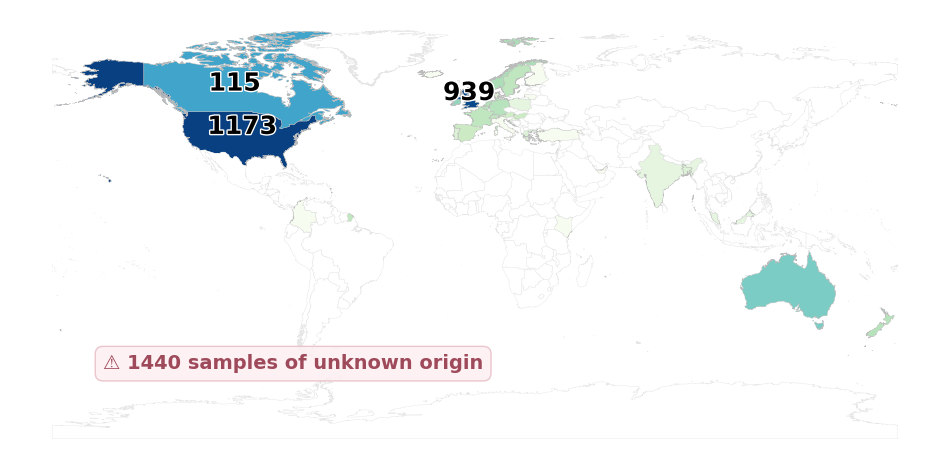

In [69]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
test_train_metadata['country_clean'] = test_train_metadata['geo_loc_name'].apply(extract_country_human_microbiome_compendium)
display_geo_counts(test_train_metadata, 'country_clean', world, ax, annotate_area_lb=1.0, annotate_count_lb=40, show_legend=False)
# ax.set_title("2018 McDonald et al. (16S Amplicon Sequencing)")

plt.savefig("amgut.png", bbox_inches='tight', dpi=800, transparent=True)

# import matplotlib
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42
# plt.savefig("amgut.pdf", bbox_inches='tight')

Text(0.5, 1.0, 'MDS-PC1 split: training set')

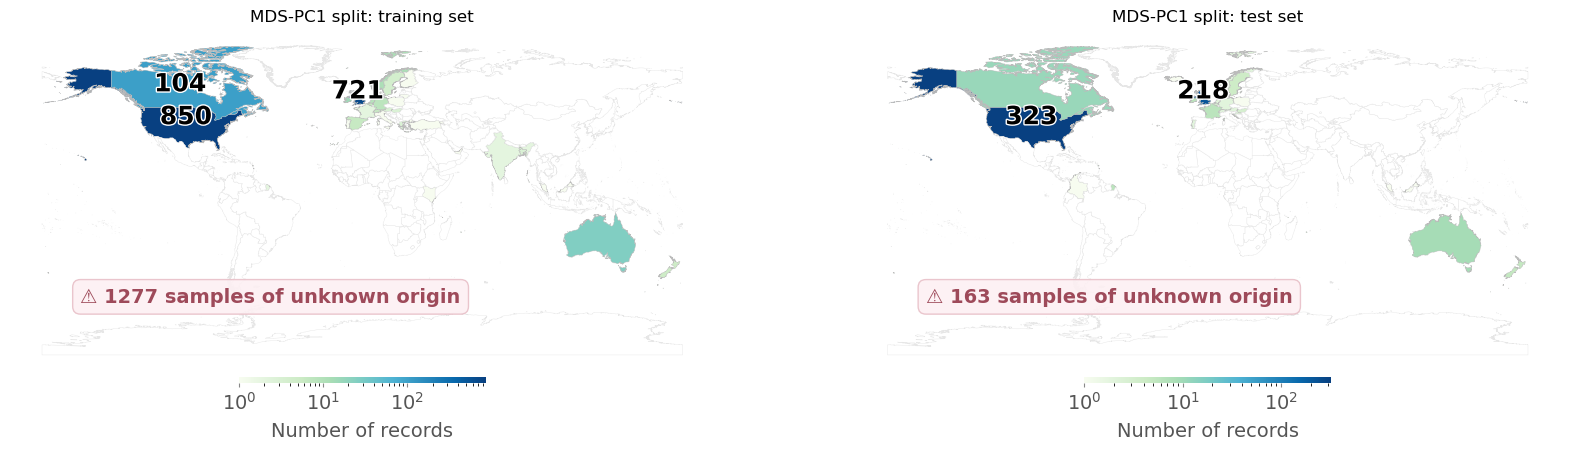

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
annotate_area_lb = 10.0  # don't annotate counts for countries smaller than this area

ax = axes[1]
test_metadata = pd.read_csv("/data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/test.tsv", sep='\t')
test_metadata['country_clean'] = test_metadata['geo_loc_name'].apply(extract_country_human_microbiome_compendium)
display_geo_counts(test_metadata, 'country_clean', world, ax, show_annotations=True, annotate_area_lb=annotate_area_lb)
ax.set_title("MDS-PC1 split: test set")

ax = axes[0]
train_metadata = pd.read_csv("/data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/train.tsv", sep='\t')
train_metadata['country_clean'] = train_metadata['geo_loc_name'].apply(extract_country_human_microbiome_compendium)
display_geo_counts(train_metadata, 'country_clean', world, ax, show_annotations=True, annotate_area_lb=annotate_area_lb)
ax.set_title("MDS-PC1 split: training set")